# Thai Text Normalization — Project Report

A rule + dictionary based Thai text normalizer, paired with a fine-tuned WangchanBERTa
sentiment classifier, evaluated on **Wisesight Sentiment** to measure whether
normalizing informal text (elongation, slang, emoji) improves sentiment classification.

This notebook is generated from the project's own pipeline code and saved results —
every table and chart below is computed from real files in this repo, not hardcoded.


## 1. Problem & Goal

Thai social text (comments, reviews, chats) breaks standard NLP models trained on formal text:

- **Elongation** — `อร่อยยยยย` (soooo delicious)
- **Slang / abbreviations** — `ทามมาย` (ทำไม), `ชิมิ` (ใช่ไหม), `555` (laughter)
- **Emoji / symbols** — 😭, T_T, 😂

Tokenizers make it worse: `word_tokenize("อร่อยยยยชิมิ")` splits into
`['อร่อย', 'ยยย', 'ชิ', 'มิ']` — elongation has to be fixed *before* tokenizing, not after.

**Goal:** build `normalize_thai()` and measure whether it raises sentiment-classification
accuracy / macro-F1 versus raw text, using a controlled fine-tuning experiment.


In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.normalize import normalize_thai  # noqa: E402

RESULTS = ROOT / "results"

def load_metrics(variant):
    with open(RESULTS / f"{variant}_metrics.json", encoding="utf-8") as f:
        return json.load(f)

def load_predictions(variant):
    rows = []
    with open(RESULTS / f"{variant}_predictions.jsonl", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

raw_metrics = load_metrics("raw")
norm_metrics = load_metrics("normalized")
raw_preds = load_predictions("raw")
norm_preds = load_predictions("normalized")

print("Loaded metrics for", len(raw_preds), "test examples (raw) and", len(norm_preds), "(normalized)")


Loaded metrics for 2671 test examples (raw) and 2671 (normalized)


## 2. Methodology

**Normalization is rule + dictionary based, not learned** — deterministic and identical
regardless of downstream task.

- Runs **character-level fixes first** (elongation, emoji/emoticons), *before* tokenizing
- Runs **token-level correction second** (slang dictionary lookup) on the already-tokenized text
- The slang dictionary is majority-vote statistics mined from MultiLexNorm++'s annotated
  corpus (17k+ entries), filtered to entries seen ≥3 times

**Sentiment classification is transfer learning, not training from scratch**

- Base model: `airesearch/wangchanberta-base-att-spm-uncased` (RoBERTa-family, pretrained on Thai text)
- New classification head (4 labels), randomly initialized, trained from there
- Loss: cross-entropy · Optimizer: AdamW · LR: 5e-5, linear decay, no warmup
- 3 epochs, batch size 32, max sequence length 64 tokens

**The raw-vs-normalized comparison is a controlled experiment** — exactly one variable
changes between the two training runs: same model, same hyperparameters, same seed (42),
same train/validation/test split. Only the input text differs (`texts` column vs.
`normalize_thai(text)["normalized_text"]`).

### `normalize_thai()` in action


In [2]:
examples = [
    "อาหารช้ามากกกกก มั้ยอ่ะ เค้าไม่ชอบ 😭😭😭",
    "ของมาไวมากกก แพ็คดีสุดๆ ประทับใจค่ะ",
    "ได้หมดถ้าสดชื่น...555",
]

for text in examples:
    result = normalize_thai(text)
    print("raw:       ", text)
    print("normalized:", result["normalized_text"])
    print("corrections:", result["corrections"])
    print("-" * 60)


raw:        อาหารช้ามากกกกก มั้ยอ่ะ เค้าไม่ชอบ 😭😭😭
normalized: อาหาร ช้า มาก ไหม อะ เขา ไม่ ชอบ [neg_emoji] [neg_emoji] [neg_emoji]
corrections: [{'original': 'อาหารช้ามากกกกก มั้ยอ่ะ เค้าไม่ชอบ 😭😭😭', 'normalized': 'อาหารช้ามาก มั้ยอ่ะ เค้าไม่ชอบ 😭😭😭', 'type': 'elongation'}, {'original': 'อาหารช้ามาก มั้ยอ่ะ เค้าไม่ชอบ 😭😭😭', 'normalized': 'อาหารช้ามาก มั้ยอ่ะ เค้าไม่ชอบ [neg_emoji] [neg_emoji] [neg_emoji]', 'type': 'emoji'}, {'original': 'มั้ย', 'normalized': 'ไหม', 'type': 'slang_dict'}, {'original': 'อ่ะ', 'normalized': 'อะ', 'type': 'slang_dict'}, {'original': 'เค้า', 'normalized': 'เขา', 'type': 'slang_dict'}]
------------------------------------------------------------
raw:        ของมาไวมากกก แพ็คดีสุดๆ ประทับใจค่ะ
normalized: ของ มา ไว มาก แพ็ค ดี สุด ๆ ประทับใจ ค่ะ
corrections: [{'original': 'ของมาไวมากกก แพ็คดีสุดๆ ประทับใจค่ะ', 'normalized': 'ของมาไวมาก แพ็คดีสุดๆ ประทับใจค่ะ', 'type': 'elongation'}]
------------------------------------------------------------
raw:        ได้

## 3. Datasets

| Dataset | Purpose | Notes |
|---|---|---|
| [`hadung1802/mlnorm-resources`](https://huggingface.co/datasets/hadung1802/mlnorm-resources) | Slang/lexical normalization pairs (Thai) | `test.norm` is a blind set (labels blanked) — `dev.norm` used instead |
| [`pythainlp/wisesight_sentiment`](https://huggingface.co/datasets/pythainlp/wisesight_sentiment) | Sentiment labels (pos/neu/neg/q) | Primary dataset — train/val/test split used as-is |

Wisesight's labels are imbalanced (`neu` ~55%, `neg` ~25%, `pos` ~18%, `q` ~2%), which is why
this report tracks **macro-F1 alongside accuracy** — accuracy alone would hide how the
minority classes perform.


In [3]:
wisesight_dir = ROOT / "data" / "raw" / "wisesight"
for split in ["train", "validation", "test"]:
    path = wisesight_dir / f"{split}.jsonl"
    labels = [json.loads(line)["label"] for line in open(path, encoding="utf-8")]
    counts = pd.Series(labels).value_counts()
    print(f"{split:<12} n={len(labels):<6} " + "  ".join(f"{k}={v}" for k, v in counts.items()))


train        n=21628  neu=11795  neg=5491  pos=3866  q=476
validation   n=2404   neu=1291  neg=637  pos=434  q=42
test         n=2671   neu=1453  neg=683  pos=478  q=57


## 4. Results

### Accuracy / macro-F1, raw vs. normalized

In [4]:
summary = pd.DataFrame(
    {
        "Accuracy": [raw_metrics["accuracy"], norm_metrics["accuracy"]],
        "Macro-F1": [raw_metrics["macro_f1"], norm_metrics["macro_f1"]],
    },
    index=["Raw text", "Normalized text"],
)
summary.round(4)


,Accuracy,Macro-F1
Raw text,0.7435,0.6428
Normalized text,0.7432,0.6551


In [5]:
labels = raw_metrics["label_names"]
per_class = pd.DataFrame(
    {
        "raw": [raw_metrics["per_class_f1"][l] for l in labels],
        "normalized": [norm_metrics["per_class_f1"][l] for l in labels],
    },
    index=labels,
)
per_class["delta"] = per_class["normalized"] - per_class["raw"]
per_class.round(4)


,raw,normalized,delta
pos,0.4975,0.5293,0.0318
neu,0.7944,0.7900,-0.0043
neg,0.7895,0.7916,0.0021
q,0.4898,0.5094,0.0196


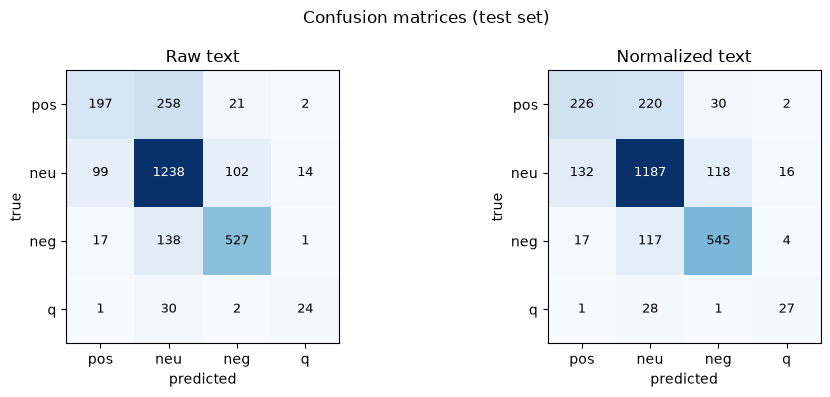

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metrics, title in zip(axes, [raw_metrics, norm_metrics], ["Raw text", "Normalized text"]):
    cm = np.array(metrics["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(4)); ax.set_xticklabels(labels)
    ax.set_yticks(range(4)); ax.set_yticklabels(labels)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(4):
        for j in range(4):
            value = cm[i, j]
            color = "white" if value > cm.max() / 2 else "black"
            ax.text(j, i, value, ha="center", va="center", color=color, fontsize=9)
fig.suptitle("Confusion matrices (test set)")
fig.tight_layout()
plt.show()


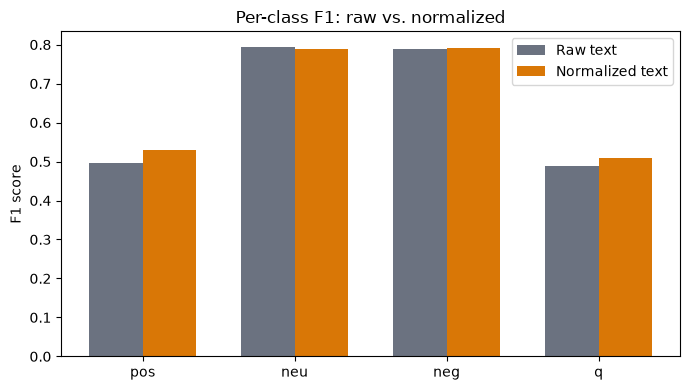

In [7]:
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, per_class["raw"], width, label="Raw text", color="#6b7280")
ax.bar(x + width / 2, per_class["normalized"], width, label="Normalized text", color="#d97706")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1: raw vs. normalized")
ax.legend()
fig.tight_layout()
plt.show()


**Takeaway:** accuracy barely moves (74.35% → 74.32%, dominated by the majority `neu`/`neg`
classes), but **macro-F1 improves by +1.2pp** (64.28% → 65.51%), driven almost entirely by
the minority classes — `pos` +3.2pp, `q` +1.9pp.


## 5. Error Analysis

Which individual test-set predictions actually changed, and why.

In [8]:
def diff_cases(direction):
    out = []
    for r, n in zip(raw_preds, norm_preds):
        match = (not r["correct"] and n["correct"]) if direction == "fixed" else (r["correct"] and not n["correct"])
        if match:
            out.append({"raw_text": r["text"], "normalized_text": n["text"], "true": r["true_label"],
                        "raw_pred": r["pred_label"], "norm_pred": n["pred_label"]})
    return out

fixed = diff_cases("fixed")
regressed = diff_cases("regressed")

fixed_with_correction = [c for c in fixed if normalize_thai(c["raw_text"])["corrections"]]
fixed_spacing_only = [c for c in fixed if not normalize_thai(c["raw_text"])["corrections"]]

print(f"{len(fixed)} predictions flipped wrong -> correct")
print(f"  {len(fixed_with_correction)} had an actual normalize_thai() correction")
print(f"  {len(fixed_spacing_only)} had NO correction -- fixed by tokenizer spacing alone")
print(f"{len(regressed)} predictions flipped correct -> wrong")
print(f"Net change: {len(fixed) - len(regressed)} more correct predictions")


174 predictions flipped wrong -> correct
  116 had an actual normalize_thai() correction
  58 had NO correction -- fixed by tokenizer spacing alone
175 predictions flipped correct -> wrong
Net change: -1 more correct predictions


Almost exactly as many predictions were fixed as were broken (174 vs. 175) — that's *why*
accuracy barely moves. But the two sets of flips aren't spread evenly across classes: fixes
land disproportionately on the minority classes (`pos`/`q`), while regressions land
disproportionately on classes (`neu`/`neg`) that had plenty of correct predictions to spare
— a redistribution that improves macro-F1 without changing raw accuracy much.

### Example: normalization fixed the prediction


In [9]:
for case in fixed_with_correction[:3]:
    print("raw:       ", case["raw_text"])
    print("normalized:", case["normalized_text"])
    print(f"true={case['true']}  raw_pred={case['raw_pred']} -> normalized_pred={case['norm_pred']}")
    print("-" * 60)


raw:        มาชมเรวๆๆ
normalized: มา ชม เร วๆ
true=neu  raw_pred=pos -> normalized_pred=neu
------------------------------------------------------------
raw:        เบอร์8อิโดนิเชียเล่นดีจิงๆแต่ไทยก็ไม่คมถ้าเล่นแบบนี้ก็ยุแต่ในอาเชียนเถอะคับ คลองบอลก็น้อยกว่าเขา โค๊ชใหม่ก็ไม่เข้าใจเท่ากับโค๊ชคนไทยด้วยกัน บอลไทยกำลังกลับไปยุในยุกเดิม มืดมน ขอบคุณเบียร์ช้างที่สนับสนุน ผมอย่างเป็นทางการ
normalized: เบอร์ 8 อี โด  เชีย เล่น ดี  แต่ ไทย ก็ ไม่ คม ถ้า เล่น  ก็ อยู่ แต่ ใน อา เชีย น เถอะ ครับ คลอง  ก็ น้อยกว่า เขา โค๊ช ใหม่ ก็ ไม่ เข้าใจ เท่ากับ โค๊ช คนไทย ด้วยกัน  ไทย กำลัง กลับ ไป อยู่ ใน อยู่ ก เดิม มืดมน ขอบคุณ เบียร์ ช้าง ที่ สนับสนุน ผม อย่าง เป็นทางการ
true=neu  raw_pred=neg -> normalized_pred=neu
------------------------------------------------------------
raw:        แม่หญิงใช้ อายไลเนอร์ มิสทีน รุ่น ซุปเปอร์แบล็ค ฟิคซ์อายไลเนอร์ ข้าอยากใช้เพราะ เส้นคม ดำสนิท ติดทนนาน ให้ดวงตาสวยเฉียบคมมีเสน่ห์ และมิสทีนของออเจ้า ไม่เคยทำให้ข้าผิดหวัง
normalized: แม่ หญิง ใช้ อาย ไลเนอร์ มิสทีน รุ่น ซ

### Example: normalization broke the prediction

In [10]:
for case in regressed[:3]:
    print("raw:       ", case["raw_text"])
    print("normalized:", case["normalized_text"])
    print(f"true={case['true']}  raw_pred={case['raw_pred']} -> normalized_pred={case['norm_pred']}")
    print("-" * 60)


raw:        เจ้ว่าการ์นิเย่แอบแรงนิสหน่อย เคยใช้โยเกิร์ตไม๊ พรุ้งนี้ลองพอกหน้าดูทำให้หน้าสบายขึ้น นุ่มขึ้น หายไวไวน๊าาาา
normalized: เจ๊ ว่า การ์  เย่ แอ บแรง  สห น่อย เคย ใช้ โยเกิร์ต ไม๊ พ รุ้ง นี้ ลอง พอก หน้า ดู ทำ ให้หน้า สบาย ขึ้น นุ่ม ขึ้น หาย ไว ไว นะ
true=neg  raw_pred=neg -> normalized_pred=neu
------------------------------------------------------------
raw:        สำหรับงาน Transmisson : The Spirit of Warrior ต้องขวดนี้ค่ะ Jack Daniel's Tennessee Whiskey honey ป็นวิสกี้ที่โดดเด่นในเรื่องของความหอมหวานราวกับน้ำผึ้ง(เดือน5) เพราะนำเอา Honey Liqueur ถึง 4 ชนิดผสมเข้าไป ทำให้ได้รสเข้มข้นเหมือนกับดื่มน้ำผึ้งอยู่จริง ๆ แต่ไม่ได้หวานมากจนบาดคอนะคะ ผู้ชายก็ชอบผู้หญิงก็ต้องบอกว่าใช่!! แล้วเจอกันค่ะ <3
normalized: สำหรับ งาน Transmisson : The Spirit of Warrior ต้อง ขวด นี้ ค่ะ Jack Daniel 's Tennessee Whiskey honey ป็น วิสกี้ ที่ โดดเด่น ใน เรื่อง ของ ความ หอม หวาน ราวกับ น้ำผึ้ง ( เดือน 5 ) เพราะ นำ เอา Honey Liqueur ถึง 4 ชนิด ผสม เข้าไป ทำ ให้ได้  เข้มข้น เหมือนกับ ดื่ม น้ำผึ้ง อย

## 6. Limitations

- **Slang dictionary coverage is incomplete.** Only corrections mined from MultiLexNorm++'s
  annotated corpus (≥3 occurrences) are included — e.g. `ชิมิ` ("ใช่ไหม") isn't in it, so
  PyThaiNLP still mis-tokenizes it into `['ชิ', 'มิ']`.
- **Part of the improvement is a tokenization-spacing artifact, not a linguistic correction**
  — 58/174 fixed cases had zero logged corrections. The fix came from PyThaiNLP's word
  segmentation giving WangchanBERTa's subword tokenizer better boundaries, not from the
  dictionary/elongation logic itself.
- **Sarcasm and other pragmatic phenomena are out of scope.** `normalize_thai()` only fixes
  surface form; it can't recover meaning that depends on tone or context.
- **Emoji mapping is coarse** — all emoji collapse into 3 tags
  (`[pos_emoji]`/`[neg_emoji]`/`[emoji]`) rather than per-emotion granularity.
- **Metrics are from a single run**, not averaged over multiple seeds.

## 7. Conclusion

`normalize_thai()` measurably improves **macro-F1** (+1.2pp) on Wisesight Sentiment,
concentrated in the minority classes where the model has the fewest examples to fall back
on — while leaving raw accuracy roughly unchanged, since it fixes about as many predictions
as it breaks. Roughly a third of the fixes are attributable to tokenizer-spacing effects
rather than the normalization logic itself, a distinction worth isolating in any follow-up
ablation study.

**Project status:** Phases 0–4 complete (setup, cleaning, normalization core, model
fine-tuning, evaluation). Phase 5 (Gradio demo) and Phase 6 (this report) are in progress.
See [`thai-text-normalization-plan-en.md`](../thai-text-normalization-plan-en.md) for the
full plan and [`README.md`](../README.md) for setup/usage instructions.
